# Unemployment Analysis in India Using Python

# 1. Introduction

Unemployment is one of the most important economic indicators that reflects the health of a country's economy. It represents the percentage of people in the labor force who are willing and able to work but are unable to find employment.

This project analyzes unemployment data across different regions of India using Python. The analysis aims to identify unemployment patterns, compare regions, study labor participation rates, and build machine learning models to predict unemployment rates.


# 2. Problem Statement

Unemployment affects economic growth and social welfare. Understanding unemployment patterns helps policymakers identify problem areas and create employment opportunities.

The objective of this project is to analyze unemployment trends in India and identify key factors influencing unemployment.

# 3. Objectives

1. Analyze unemployment trends across India.
2. Compare unemployment rates among states.
3. Compare rural and urban unemployment.
4. Study labour participation rates.
5. Find relationships between variables.
6. Build a machine learning model to predict unemployment rates.

# 4. Dataset Description
The dataset contains unemployment statistics for various states and regions in India.
Features:
1. Region
   - Name of the state or region.
2. Date
   - Month and year of observation.
3. Frequency
   - Frequency of data collection.
4. Estimated Unemployment Rate (%)
   - Percentage of unemployed individuals.
5. Estimated Employed
   - Number of employed individuals.
6. Estimated Labour Participation Rate (%)
   - Percentage of working-age population participating in the labor force.
7. Area
   - Indicates whether the data belongs to Rural or Urban areas.

# 5. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('ggplot')

# 6. Load Dataset
The dataset contains unemployment statistics for different regions of India.


In [5]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# 7. Data Understanding
Dataset Shape
The dataset contains 768 observation across 7 features.
Features:
* Region
* Date
* Frequency
* Estimated Unemployment Rate (%)
* Estimated Employed
* Estimated Labour Participation Rate (%)
* Area (Rural/Urban)

In [6]:
df.shape

(768, 7)

In [7]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [8]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [9]:
df['Region'].nunique()

28

In [10]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', nan, 'Chandigarh'],
      dtype=object)

## Data Cleaning

In [11]:
#Missing Values
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [15]:
#Remove Empty Rows
df = df.dropna()
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [16]:
#Remove Extra Spaces
df.columns = df.columns.str.strip()

In [19]:
#Convert date column
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


# 8. Exploratory Data Analysis (EDA)

In [26]:
#Average Unemployment Rate
print("Average Unemployment Rate:",df['Estimated Unemployment Rate (%)'].mean())

Average Unemployment Rate: 11.787945945945946


In [27]:
#Maximum Unemployment Rate
print("Maximum Unemployment Rate:",df['Estimated Unemployment Rate (%)'].max())

Maximum Unemployment Rate: 76.74


In [28]:
#Minimum Unemployment Rate
print("Minimum Unemployment Rate:",df['Estimated Unemployment Rate (%)'].min())

Minimum Unemployment Rate 0.0


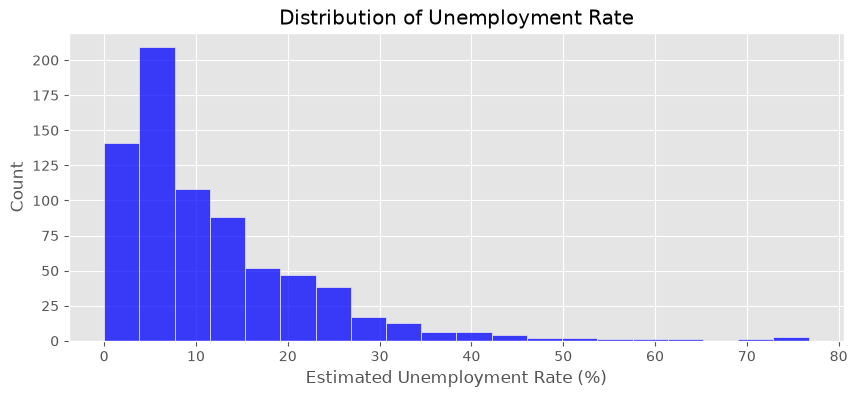

In [45]:
#Distribution of Unemployment Rate
plt.figure(figsize=(10,4))
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20,color='blue')
plt.title("Distribution of Unemployment Rate")
plt.show()

### State-wise Average Unemployment

In [36]:
unemployment_rate = (
    df.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

unemployment_rate

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

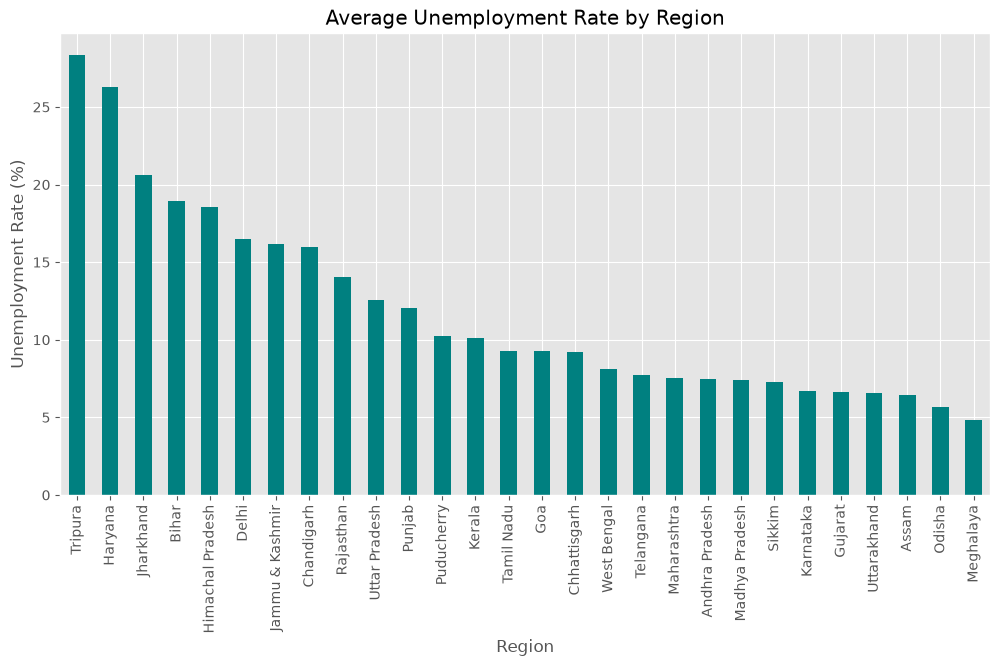

In [50]:
plt.figure(figsize=(12,6))
unemployment_rate.plot(kind='bar',color='Teal')
plt.title("Average Unemployment Rate by Region")
plt.ylabel("Unemployment Rate (%)")
plt.show()

### Top 10 States with Highest Unemployment

In [38]:
unemployment_rate.head(10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

### Rural vs Urban Analysis

In [40]:
print(df.groupby('Area')['Estimated Unemployment Rate (%)'].mean())

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


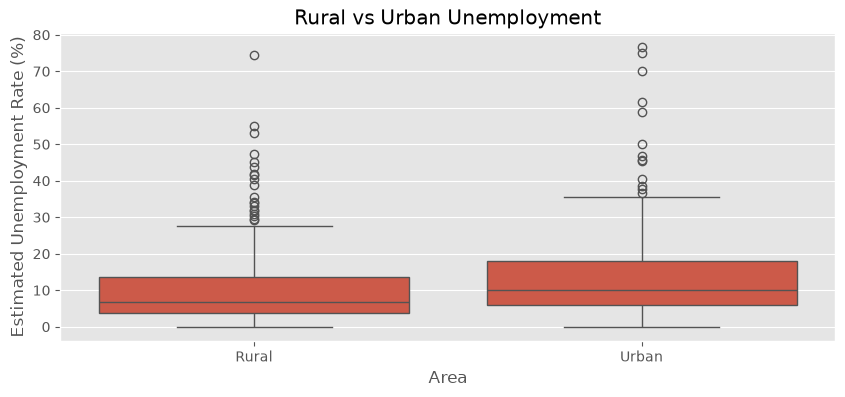

In [44]:
plt.figure(figsize=(10,4))
sns.boxplot(
    data=df,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)
plt.title("Rural vs Urban Unemployment")
plt.show()

### Employment Analysis

In [47]:
employed = (
    df.groupby('Region')
    ['Estimated Employed']
    .mean()
    .sort_values(ascending=False)
)
employed.head()

Region
Uttar Pradesh    2.809483e+07
Maharashtra      1.999020e+07
West Bengal      1.719854e+07
Bihar            1.236619e+07
Tamil Nadu       1.226955e+07
Name: Estimated Employed, dtype: float64

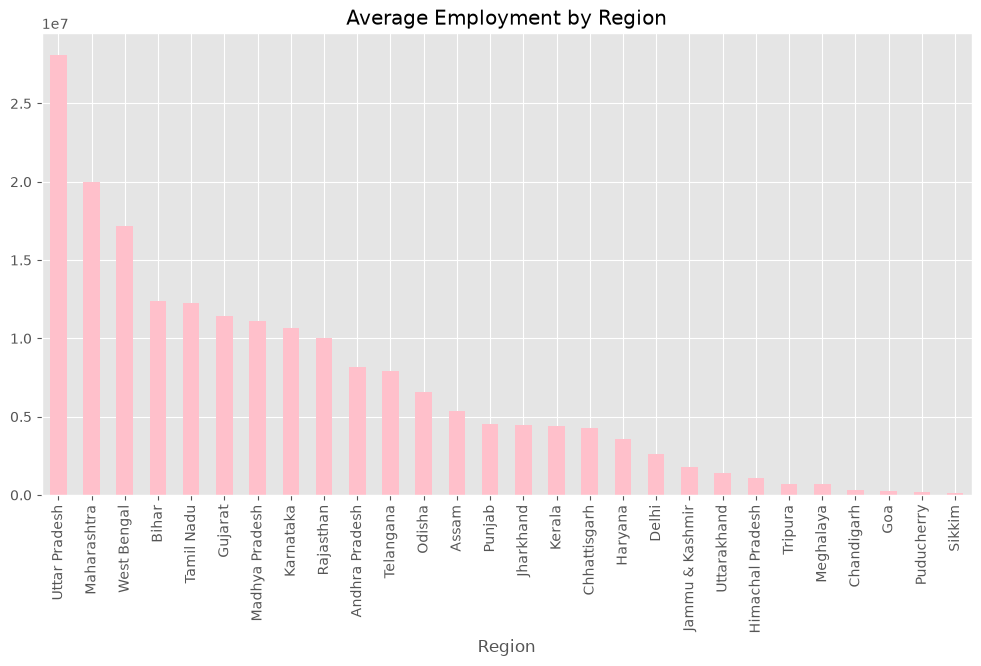

In [55]:
plt.figure(figsize=(12,6))
employed.plot(kind='bar',color='pink')
plt.title("Average Employment by Region")
plt.show()

### Labour Participation Analysis

In [56]:
labour = (
    df.groupby('Region')
    ['Estimated Labour Participation Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

labour

Region
Tripura             61.823929
Meghalaya           57.080741
Telangana           53.002500
Gujarat             46.101071
Sikkim              46.070000
West Bengal         45.417500
Assam               44.868462
Himachal Pradesh    44.222143
Chhattisgarh        42.810714
Haryana             42.737143
Maharashtra         42.303214
Jharkhand           41.670714
Karnataka           41.345357
Punjab              41.138214
Jammu & Kashmir     41.030952
Tamil Nadu          40.872143
Rajasthan           39.973214
Uttar Pradesh       39.432500
Andhra Pradesh      39.375714
Chandigarh          39.336667
Goa                 39.249583
Puducherry          38.992692
Delhi               38.929643
Odisha              38.926429
Madhya Pradesh      38.821429
Bihar               38.153929
Kerala              34.867857
Uttarakhand         33.775556
Name: Estimated Labour Participation Rate (%), dtype: float64

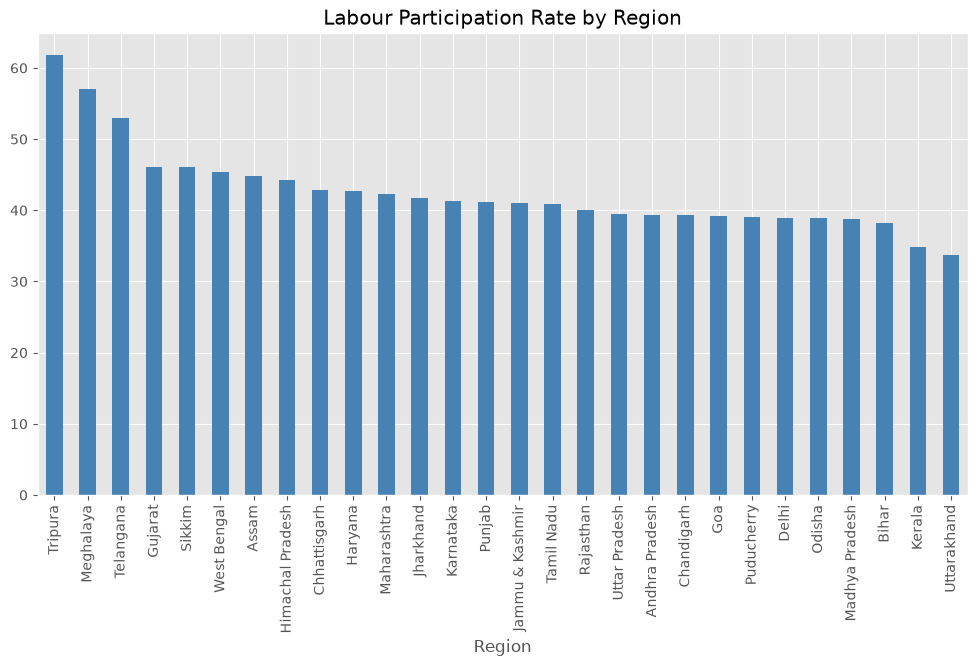

In [58]:
plt.figure(figsize=(12,6))
labour.plot(kind='bar',color='#4682B4')
plt.title("Labour Participation Rate by Region")
plt.show()

### Time Series Analysis

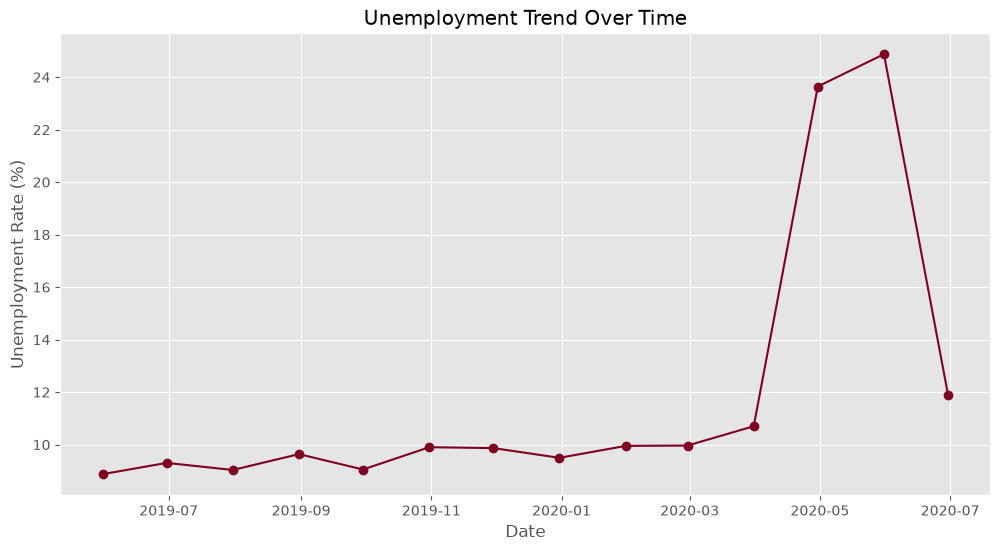

In [61]:
monthly = (
    df.groupby('Date')
    ['Estimated Unemployment Rate (%)']
    .mean()
)
plt.figure(figsize=(12,6))
plt.plot(monthly.index, monthly.values,color='#800020',marker='o')
plt.title("Unemployment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

### Correlation Analysis

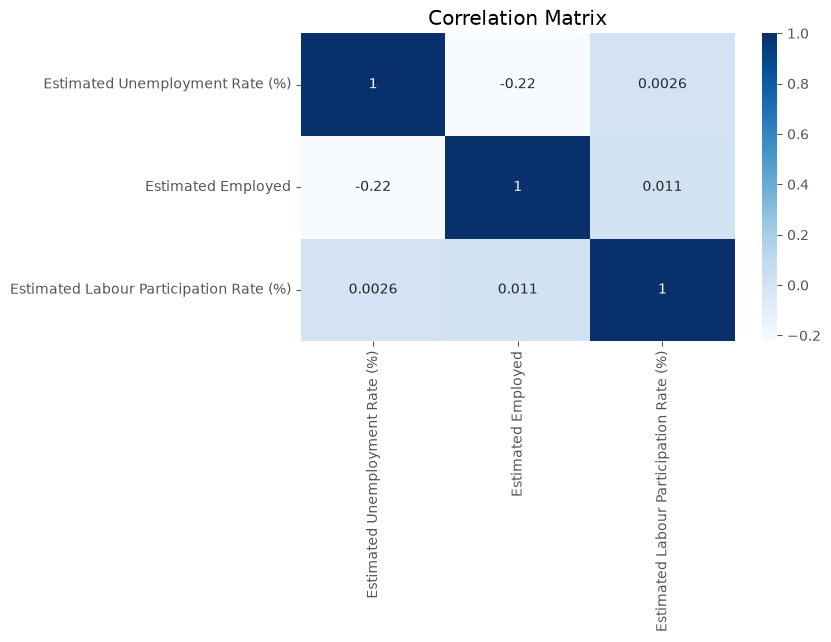

In [69]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(7,4))
sns.heatmap(corr, annot=True,cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

# 9. Feature Engineering

In [70]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [71]:
# Encode Area
df['Area'] = LabelEncoder().fit_transform(df['Area'])

In [72]:
# Encode Region
df['Region'] = LabelEncoder().fit_transform(df['Region'])

# 10. Machine Learning

In [74]:
# Define Features and Target
X = df[
    [   'Region',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)',
        'Area',
        'Year',
        'Month'
    ]
]
y = df['Estimated Unemployment Rate (%)']

In [75]:
# Split Data
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_lr)))
print("R2 Score:",r2_score(y_test,pred_lr))

MAE: 8.347144710634923
RMSE: 11.78184338002181
R2 Score: 0.041207136874072736


# 12. Random Forest Regressor

In [77]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [79]:
pred_rf = rf.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_rf)))
print("R2 Score:",r2_score(y_test,pred_rf))

MAE: 4.0586722972972975
RMSE: 7.398980238834413
R2 Score: 0.6218692143431639


# 13. Feature Importance

In [80]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False)

Estimated Employed                         0.368913
Region                                     0.270468
Estimated Labour Participation Rate (%)    0.204853
Month                                      0.096318
Year                                       0.042878
Area                                       0.016571
dtype: float64

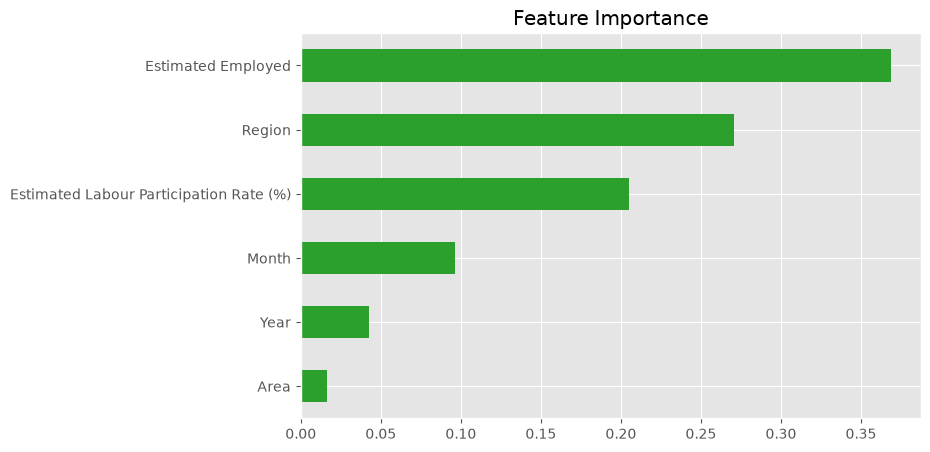

In [84]:
plt.figure(figsize=(8,5))
importance.sort_values().plot(kind='barh',color='#2ca02c')
plt.title("Feature Importance")
plt.show()